In [ ]:
!pip install imbalanced-learn --quiet
print("✅ Installation OK")

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib
import json
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from imblearn.over_sampling import SMOTE

print("✅ Imports OK")

✅ Imports OK


In [9]:
# Noms des 43 colonnes (le fichier n'a pas de header)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "attack_type","difficulty"
]

df = pd.read_csv('NSL_KDD_Train.csv', header=None, names=columns)
df = df.drop('difficulty', axis=1)

print(f"✅ Dataset chargé !")
print(f"📊 {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# Q2 — 5 premières lignes
print("\n=== 5 PREMIÈRES LIGNES ===")
display(df.head())

# Q3 — 5 dernières lignes
print("=== 5 DERNIÈRES LIGNES ===")
display(df.tail())

# Q4, Q5
print(f"\nQ4 — Lignes   : {df.shape[0]:,}")
print(f"Q5 — Colonnes : {df.shape[1]}")

# Q6 — Noms des colonnes
print("\nQ6 — Noms des colonnes :")
for i, col in enumerate(df.columns):
    print(f"  {i+1:2}. {col}")

# Q7 — Types
print("\nQ7 — Types des colonnes :")
print(df.dtypes.value_counts())
display(df.dtypes.to_frame('type'))

✅ Dataset chargé !
📊 64,378 lignes × 42 colonnes

=== 5 PREMIÈRES LIGNES ===


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25.0,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1.0,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26.0,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255.0,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255.0,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


=== 5 DERNIÈRES LIGNES ===


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type
64373,0,udp,domain_u,SF,45,125,0,0,0,0,...,254.0,1.00,0.01,0.00,0.00,0.0,0.0,0.0,0.0,normal
64374,0,tcp,whois,S0,0,0,0,0,0,0,...,12.0,0.05,0.06,0.00,0.00,1.0,1.0,0.0,0.0,neptune
64375,0,tcp,http,SF,303,3907,0,0,0,0,...,255.0,1.00,0.00,0.25,0.05,0.0,0.0,0.0,0.0,normal
64376,0,tcp,http,SF,295,4123,0,0,0,0,...,255.0,1.00,0.00,0.04,0.02,0.0,0.0,0.0,0.0,normal
64377,0,tcp,nnsp,S0,0,0,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Q4 — Lignes   : 64,378
Q5 — Colonnes : 42

Q6 — Noms des colonnes :
   1. duration
   2. protocol_type
   3. service
   4. flag
   5. src_bytes
   6. dst_bytes
   7. land
   8. wrong_fragment
   9. urgent
  10. hot
  11. num_failed_logins
  12. logged_in
  13. num_compromised
  14. root_shell
  15. su_attempted
  16. num_root
  17. num_file_creations
  18. num_shells
  19. num_access_files
  20. num_outbound_cmds
  21. is_host_login
  22. is_guest_login
  23. count
  24. srv_count
  25. serror_rate
  26. srv_serror_rate
  27. rerror_rate
  28. srv_rerror_rate
  29. same_srv_rate
  30. diff_srv_rate
  31. srv_diff_host_rate
  32. dst_host_count
  33. dst_host_srv_count
  34. dst_host_same_srv_rate
  35. dst_host_diff_srv_rate
  36. dst_host_same_src_port_rate
  37. dst_host_srv_diff_host_rate
  38. dst_host_serror_rate
  39. dst_host_srv_serror_rate
  40. dst_host_rerror_rate
  41. dst_host_srv_rerror_rate
  42. attack_type

Q7 — Types des colonnes :
int64      22
float64    16
object 

,type
duration,int64
protocol_type,object
service,object
flag,object
src_bytes,int64
dst_bytes,int64
land,int64
wrong_fragment,int64
urgent,int64
hot,int64


In [10]:
print("=== ANALYSE TIMESTAMP (Q8-Q11) ===")
timestamp_cols = [c for c in df.columns if 'time' in c.lower() or 'date' in c.lower()]

print(f"Q8  — Colonnes timestamp détectées : {timestamp_cols}")
print()
print("⚠️  NSL-KDD ne contient PAS de timestamp réel.")
print("→ Chaque ligne = 1 connexion réseau sans horodatage.")
print("→ La colonne 'duration' représente la durée de la connexion (en secondes).")
print()
print("Q9  — Formatée correctement ? Non applicable (pas de timestamp)")
print("Q10 — Conversion datetime ? Non applicable")
print("Q11 — Extraction heure/jour/mois ? Non applicable")
print()
print("💡 Solution pour le monitoring live :")
print("   → Le backend FastAPI générera un timestamp automatique")
print("   → à chaque prédiction (datetime.now())")

=== ANALYSE TIMESTAMP (Q8-Q11) ===
Q8  — Colonnes timestamp détectées : []

⚠️  NSL-KDD ne contient PAS de timestamp réel.
→ Chaque ligne = 1 connexion réseau sans horodatage.
→ La colonne 'duration' représente la durée de la connexion (en secondes).

Q9  — Formatée correctement ? Non applicable (pas de timestamp)
Q10 — Conversion datetime ? Non applicable
Q11 — Extraction heure/jour/mois ? Non applicable

💡 Solution pour le monitoring live :
   → Le backend FastAPI générera un timestamp automatique
   → à chaque prédiction (datetime.now())


In [11]:
print("=== ANALYSE VALEURS MANQUANTES (Q12-Q16) ===")

nan_counts = df.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0]

print(f"Q12 — Total NaN dans tout le dataset : {df.isnull().sum().sum()}")
print()

if len(nan_cols) == 0:
    print("✅ Aucune valeur manquante !")
    print("Q13 — Pourcentage : 0%")
    print("Q14 — Concentrées dans certaines colonnes ? Non")
    print("Q15 — Stratégie : aucune nécessaire")
    print("Q16 — Action : aucune")
else:
    print(f"⚠️  {len(nan_cols)} colonnes avec NaN :")
    display(nan_cols.to_frame('NaN count'))
    pct = (nan_cols / len(df) * 100).round(2)
    print(f"\nQ13 — Pourcentages :")
    display(pct.to_frame('%'))
    print("Q15 — Stratégie : suppression des lignes")
    df.dropna(inplace=True)
    print(f"Q16 — ✅ Fait ! Lignes restantes : {len(df):,}")

=== ANALYSE VALEURS MANQUANTES (Q12-Q16) ===
Q12 — Total NaN dans tout le dataset : 10

⚠️  10 colonnes avec NaN :


,NaN count
dst_host_srv_count,1
dst_host_same_srv_rate,1
dst_host_diff_srv_rate,1
dst_host_same_src_port_rate,1
dst_host_srv_diff_host_rate,1
dst_host_serror_rate,1
dst_host_srv_serror_rate,1
dst_host_rerror_rate,1
dst_host_srv_rerror_rate,1
attack_type,1



Q13 — Pourcentages :


,%
dst_host_srv_count,0.0
dst_host_same_srv_rate,0.0
dst_host_diff_srv_rate,0.0
dst_host_same_src_port_rate,0.0
dst_host_srv_diff_host_rate,0.0
dst_host_serror_rate,0.0
dst_host_srv_serror_rate,0.0
dst_host_rerror_rate,0.0
dst_host_srv_rerror_rate,0.0
attack_type,0.0


Q15 — Stratégie : suppression des lignes
Q16 — ✅ Fait ! Lignes restantes : 64,377


In [12]:
print("=== ANALYSE DOUBLONS (Q17-Q19) ===")

dupes = df.duplicated().sum()
print(f"Q17 — Doublons trouvés : {dupes:,}")
print(f"       Pourcentage     : {dupes/len(df)*100:.2f}%")

if dupes > 0:
    df.drop_duplicates(inplace=True)
    print(f"Q18 — ✅ Doublons supprimés !")
    print(f"       Lignes restantes : {len(df):,}")
else:
    print("Q18 — ✅ Aucun doublon à supprimer")

print(f"Q19 — Vérification : {df.duplicated().sum()} doublon(s) restant(s)")

=== ANALYSE DOUBLONS (Q17-Q19) ===
Q17 — Doublons trouvés : 0
       Pourcentage     : 0.00%
Q18 — ✅ Aucun doublon à supprimer
Q19 — Vérification : 0 doublon(s) restant(s)


=== ENCODAGE COLONNES TEXTE ===
✅ protocol_type → protocol_type_enc (3 valeurs uniques)
✅ service → service_enc (69 valeurs uniques)
✅ flag → flag_enc (11 valeurs uniques)

=== MAPPING 5 CLASSES ===
✅ Mapping OK !

Distribution des 5 classes :
attack_class
Normal    34203
DoS       23612
Probe      5996
R2L         539
U2R          27
Name: count, dtype: int64
=== DISTRIBUTIONS & VALEURS ABERRANTES (Q20-Q23) ===


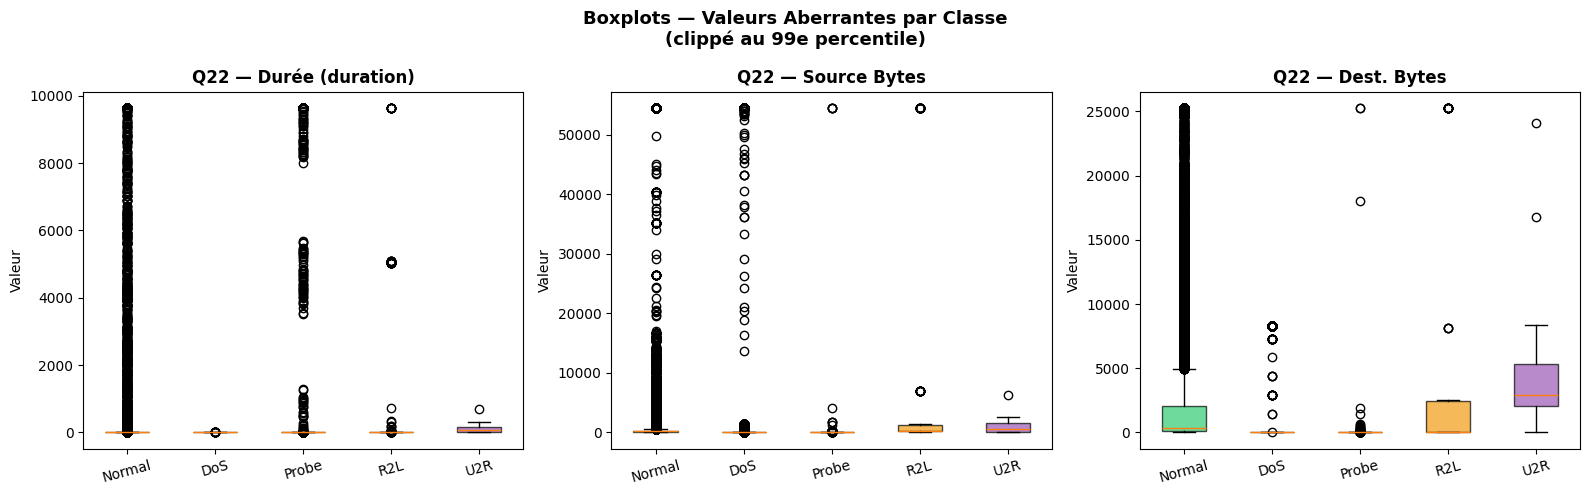

✅ Q21 — Oui, valeurs aberrantes présentes (src_bytes, dst_bytes très élevés pour DoS)
✅ Q23 — Durée, src_bytes et dst_bytes montrent des anomalies claires pour DoS


In [13]:
print("=== ENCODAGE COLONNES TEXTE ===")
le = LabelEncoder()
for col in ['protocol_type', 'service', 'flag']:
    df[col + '_enc'] = le.fit_transform(df[col])
    print(f"✅ {col} → {col}_enc ({df[col].nunique()} valeurs uniques)")

print("\n=== MAPPING 5 CLASSES ===")
attack_map = {
    'normal'          : 'Normal',
    # DoS — Déni de service
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS',
    'smurf':'DoS','teardrop':'DoS','mailbomb':'DoS',
    'apache2':'DoS','processtable':'DoS','udpstorm':'DoS',
    # Probe — Reconnaissance
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe',
    'satan':'Probe','mscan':'Probe','saint':'Probe',
    # R2L — Remote to Local
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L',
    'multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L',
    'named':'R2L','snmpgetattack':'R2L','snmpguess':'R2L',
    'xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    # U2R — User to Root
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R',
    'rootkit':'U2R','xterm':'U2R','ps':'U2R',
    'sqlattack':'U2R','worm':'U2R',
}

df['attack_class'] = df['attack_type'].map(attack_map)

# Vérifier si des attaques ne sont pas mappées
unmapped = df[df['attack_class'].isna()]['attack_type'].unique()
if len(unmapped) > 0:
    print(f"⚠️  Non mappées → Normal par défaut : {unmapped}")
    df['attack_class'].fillna('Normal', inplace=True)

print("✅ Mapping OK !")
print(f"\nDistribution des 5 classes :")
print(df['attack_class'].value_counts())
"""

# ╔══════════════════════════════════════════════╗
# ║  CELLULE 9 — Boxplots (Q20-Q23)            ║
# ╚══════════════════════════════════════════════╝
"""
print("=== DISTRIBUTIONS & VALEURS ABERRANTES (Q20-Q23) ===")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['duration', 'src_bytes', 'dst_bytes']
labels   = ['Durée (duration)', 'Source Bytes', 'Dest. Bytes']
classes  = ['Normal','DoS','Probe','R2L','U2R']
colors   = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']

for i, (feat, label) in enumerate(zip(features, labels)):
    data = [
        df[df['attack_class']==c][feat].clip(upper=df[feat].quantile(0.99))
        for c in classes
    ]
    bp = axes[i].boxplot(data, labels=classes, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f'Q22 — {label}', fontweight='bold')
    axes[i].set_ylabel('Valeur')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Boxplots — Valeurs Aberrantes par Classe\n(clippé au 99e percentile)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()
print("✅ Q21 — Oui, valeurs aberrantes présentes (src_bytes, dst_bytes très élevés pour DoS)")
print("✅ Q23 — Durée, src_bytes et dst_bytes montrent des anomalies claires pour DoS")


=== MATRICE DE CORRÉLATION (Q24-Q25) ===
Q24 — Top 15 features corrélées avec la classe d'attaque :


,Corrélation (abs)
dst_host_srv_serror_rate,0.6740
dst_host_serror_rate,0.6726
srv_serror_rate,0.6711
serror_rate,0.6698
same_srv_rate,0.6267
count,0.4866
dst_host_same_srv_rate,0.4659
dst_host_same_src_port_rate,0.4514
dst_host_count,0.4276
flag_enc,0.4086


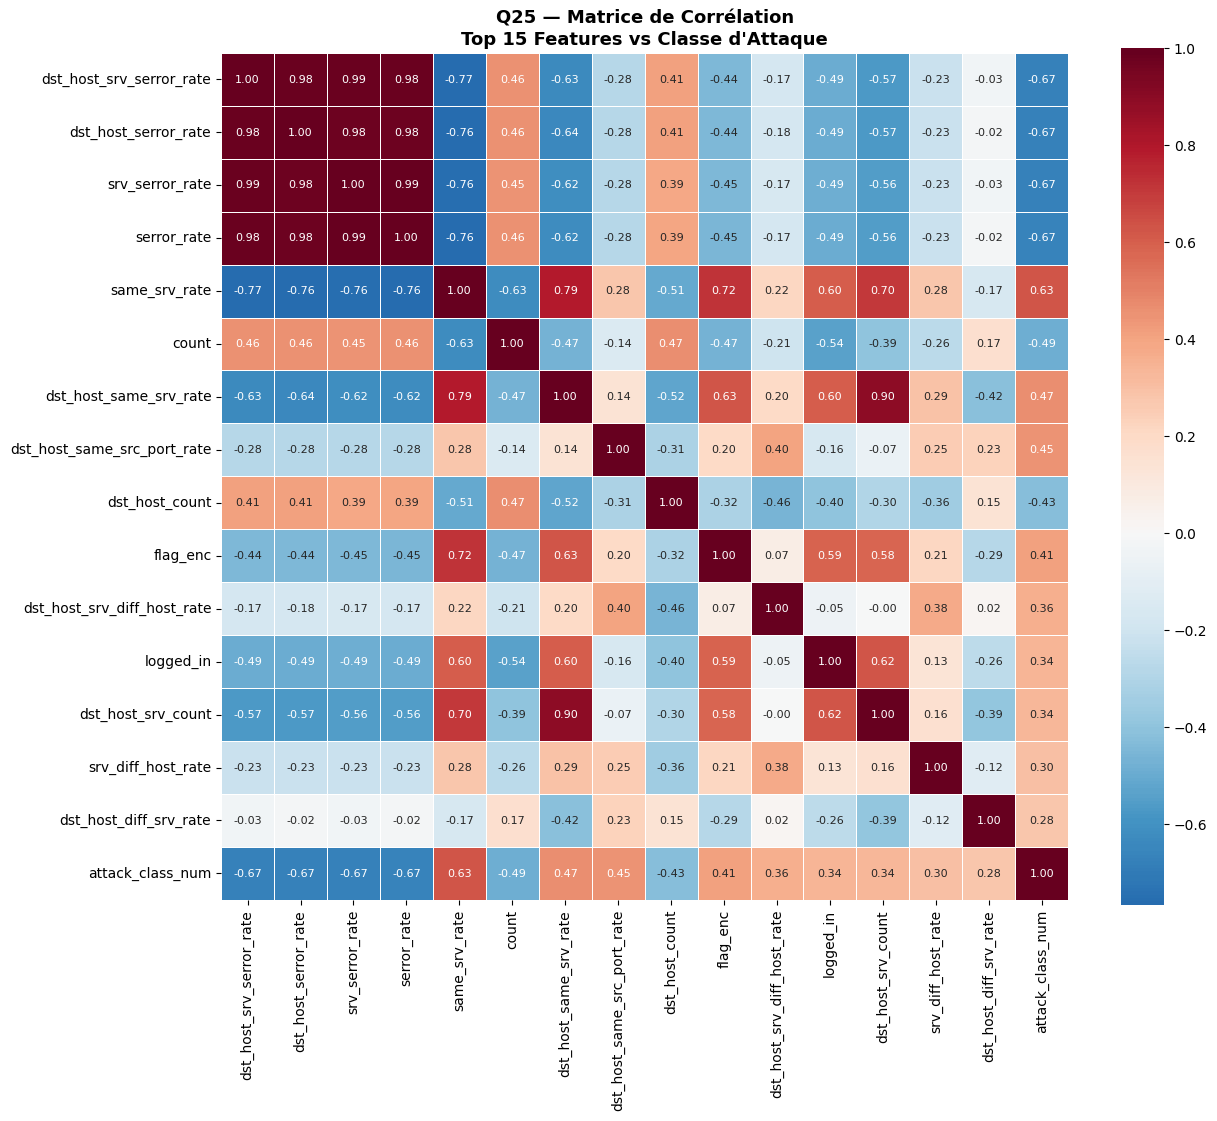

In [14]:
print("=== MATRICE DE CORRÉLATION (Q24-Q25) ===")

# Encoder la classe pour calculer la corrélation
le_class = LabelEncoder()
df['attack_class_num'] = le_class.fit_transform(df['attack_class'])

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feat_cols = [c for c in num_cols if c != 'attack_class_num']

corr_target = df[feat_cols + ['attack_class_num']].corr()['attack_class_num'].abs()
top15 = corr_target.sort_values(ascending=False)[1:16]

print("Q24 — Top 15 features corrélées avec la classe d'attaque :")
display(top15.round(4).to_frame('Corrélation (abs)'))

# Heatmap
plt.figure(figsize=(13, 11))
top_feat   = top15.index.tolist()
corr_matrix = df[top_feat + ['attack_class_num']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={'size':8})
plt.title("Q25 — Matrice de Corrélation\nTop 15 Features vs Classe d'Attaque",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

=== ANALYSE VARIABLE CIBLE (Q26-Q29) ===
Q26 — Distribution des 5 classes :
   Normal     : 34,203  (53.1%)
   DoS        : 23,612  (36.7%)
   Probe      :  5,996  (9.3%)
   R2L        :    539  (0.8%)
   U2R        :     27  (0.0%)

Q27 — Dataset équilibré ? NON
       Dominant : Normal (53%)
       Très rare : U2R (27 lignes seulement)

Q28 — % attaques : 46.9%


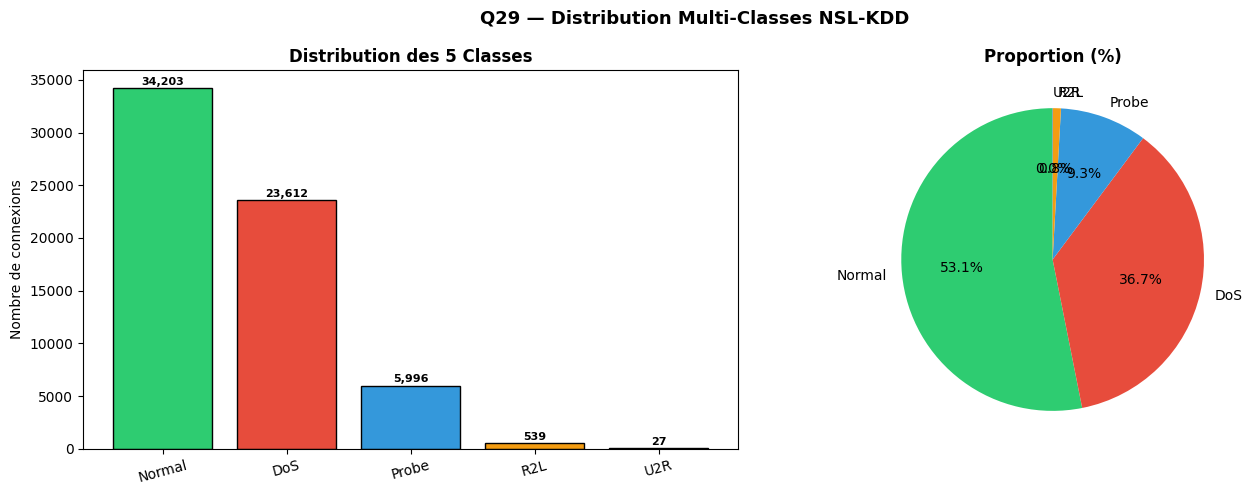


Q30 — ✅ Dataset propre sauvegardé : clean_network_dataset.csv
       Shape : (64377, 47)


In [15]:
print("=== ANALYSE VARIABLE CIBLE (Q26-Q29) ===")

class_counts = df['attack_class'].value_counts()
total = len(df)

print("Q26 — Distribution des 5 classes :")
for cls, cnt in class_counts.items():
    print(f"   {cls:10} : {cnt:6,}  ({cnt/total*100:.1f}%)")

print(f"\nQ27 — Dataset équilibré ? NON")
print(f"       Dominant : Normal ({class_counts['Normal']/total*100:.0f}%)")
print(f"       Très rare : U2R ({class_counts['U2R']:,} lignes seulement)")
print(f"\nQ28 — % attaques : {(total - class_counts['Normal'])/total*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6']

# Barplot
axes[0].bar(class_counts.index, class_counts.values,
            color=colors, edgecolor='black')
axes[0].set_title('Distribution des 5 Classes', fontweight='bold')
axes[0].set_ylabel('Nombre de connexions')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 300, f'{v:,}', ha='center', fontweight='bold', fontsize=8)
axes[0].tick_params(axis='x', rotation=15)

# Pie
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Proportion (%)', fontweight='bold')

plt.suptitle("Q29 — Distribution Multi-Classes NSL-KDD",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

# Sauvegarde dataset propre (Q30)
df.to_csv('clean_network_dataset.csv', index=False)
print("\nQ30 — ✅ Dataset propre sauvegardé : clean_network_dataset.csv")
print(f"       Shape : {df.shape}")

=== ÉTAPE 3 — DATA SPLIT ===
✅ X : (64377, 41) | y : (64377,)

Features utilisées (41) :
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'protocol_type_enc', 'service_enc', 'flag_enc']

── Normalisation StandardScaler ──
✅ StandardScaler appliqué

── Split 70% / 15% / 15% ──
Train      : 36,050 lignes
Validation : 9,013 lignes
Test       : 19,314 lignes

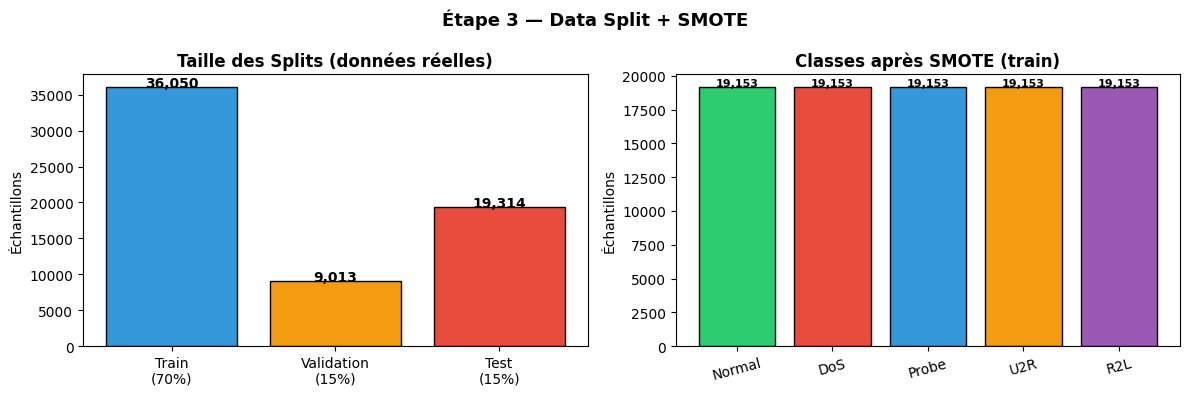

In [16]:
print("=== ÉTAPE 3 — DATA SPLIT ===")

# Supprimer les colonnes non numériques et cibles
cols_to_drop = ['attack_type','attack_class','attack_class_num',
                'protocol_type','service','flag']
X = df.drop(columns=cols_to_drop).select_dtypes(include=[np.number]).copy()
y = df['attack_class'].copy()

print(f"✅ X : {X.shape} | y : {y.shape}")
print(f"\nFeatures utilisées ({len(X.columns)}) :")
print(list(X.columns))

# Normalisation StandardScaler
print("\n── Normalisation StandardScaler ──")
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ StandardScaler appliqué")

# Split 70/15/15 AVANT SMOTE
print("\n── Split 70% / 15% / 15% ──")
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)

print(f"Train      : {len(X_train):,} lignes")
print(f"Validation : {len(X_val):,} lignes")
print(f"Test       : {len(X_test):,} lignes")

print("\n── Distribution avant SMOTE ──")
print(pd.Series(y_train).value_counts())

# SMOTE sur TRAIN uniquement
print("\n── Application SMOTE sur TRAIN ──")
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\n✅ Après SMOTE (train) :")
print(pd.Series(y_train_bal).value_counts())
print(f"\nTotal train balancé : {len(X_train_bal):,}")
print("⚠️  Test et Val restent réels — JAMAIS de SMOTE dessus !")

# Visualisation splits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
splits = ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
sizes  = [len(X_train), len(X_val), len(X_test)]
axes[0].bar(splits, sizes, color=['#3498db','#f39c12','#e74c3c'], edgecolor='black')
axes[0].set_title('Taille des Splits (données réelles)', fontweight='bold')
axes[0].set_ylabel("Échantillons")
for i, v in enumerate(sizes):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

smote_counts = pd.Series(y_train_bal).value_counts()
axes[1].bar(smote_counts.index, smote_counts.values,
            color=['#2ecc71','#e74c3c','#3498db','#f39c12','#9b59b6'], edgecolor='black')
axes[1].set_title('Classes après SMOTE (train)', fontweight='bold')
axes[1].set_ylabel("Échantillons")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(smote_counts.values):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold', fontsize=8)

plt.suptitle('Étape 3 — Data Split + SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('data_split.png', dpi=150)
plt.show()

In [17]:
print("=== ÉTAPE 4 — ENTRAÎNEMENT DES 4 MODÈLES ===\n")
results = {}

# 1. LOGISTIC REGRESSION
print("📊 1. Logistic Regression...")
start = time.time()
lr_model = LogisticRegression(
    max_iter=1000, random_state=42, n_jobs=-1,
    multi_class='multinomial', solver='lbfgs'
)
lr_model.fit(X_train_bal, y_train_bal)
t = time.time() - start

y_pred  = lr_model.predict(X_test)
y_proba = lr_model.predict_proba(X_test)
results['Logistic Regression'] = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'auc'      : roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'),
    'time'     : round(t, 2), 'y_pred': y_pred, 'y_proba': y_proba,
}
print(f"   ✅ Acc={results['Logistic Regression']['accuracy']:.4f} | F1={results['Logistic Regression']['f1']:.4f} | {t:.2f}s")

# 2. KNN
print("\n📊 2. KNN (K=3, 5, 7)...")
best_k, best_f1_knn, best_knn = None, 0, None
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_bal, y_train_bal)
    f1_k  = f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0)
    acc_k = accuracy_score(y_test, knn.predict(X_test))
    print(f"   K={k} → F1={f1_k:.4f} | Acc={acc_k:.4f}")
    if f1_k > best_f1_knn:
        best_f1_knn, best_k, best_knn = f1_k, k, knn

print(f"   🏆 Meilleur K = {best_k}")
y_pred  = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)
results['KNN'] = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'auc'      : roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'),
    'time'     : 0, 'y_pred': y_pred, 'y_proba': y_proba,
}
print(f"   ✅ Acc={results['KNN']['accuracy']:.4f} | F1={results['KNN']['f1']:.4f}")

# 3. RANDOM FOREST
print("\n📊 3. Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=20, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)
t = time.time() - start

y_pred  = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)
results['Random Forest'] = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'auc'      : roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'),
    'time'     : round(t, 2), 'y_pred': y_pred, 'y_proba': y_proba,
}
feat_imp = pd.DataFrame({
    'feature'   : X.columns.tolist(),
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"   ✅ Acc={results['Random Forest']['accuracy']:.4f} | F1={results['Random Forest']['f1']:.4f} | {t:.2f}s")
print(f"   Top 5 : {feat_imp['feature'].head(5).tolist()}")

# 4. SVM
print("\n📊 4. SVM (patience ☕)...")
start = time.time()
svm_model = SVC(
    kernel='rbf', probability=True, random_state=42,
    class_weight='balanced', decision_function_shape='ovr'
)
svm_model.fit(X_train_bal, y_train_bal)
t = time.time() - start

y_pred  = svm_model.predict(X_test)
y_proba = svm_model.predict_proba(X_test)
results['SVM'] = {
    'accuracy' : accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'recall'   : recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'f1'       : f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'auc'      : roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted'),
    'time'     : round(t, 2), 'y_pred': y_pred, 'y_proba': y_proba,
}
print(f"   ✅ Acc={results['SVM']['accuracy']:.4f} | F1={results['SVM']['f1']:.4f} | {t:.2f}s")

# Tableau comparatif
print("\n" + "="*65)
print("TABLEAU COMPARATIF DES 4 MODÈLES")
print("="*65)
df_results = pd.DataFrame({
    'Modèle'   : list(results.keys()),
    'Accuracy' : [results[m]['accuracy']  for m in results],
    'Precision': [results[m]['precision'] for m in results],
    'Recall'   : [results[m]['recall']    for m in results],
    'F1-Score' : [results[m]['f1']        for m in results],
    'ROC-AUC'  : [results[m]['auc']       for m in results],
    'Temps (s)': [results[m]['time']      for m in results],
}).round(4)

display(df_results)
best_model_name = df_results.loc[df_results['F1-Score'].idxmax(), 'Modèle']
print(f"\n🏆 Meilleur modèle (F1-Score) : {best_model_name}")

=== ÉTAPE 4 — ENTRAÎNEMENT DES 4 MODÈLES ===

📊 1. Logistic Regression...
   ✅ Acc=0.9419 | F1=0.9481 | 16.11s

📊 2. KNN (K=3, 5, 7)...
   K=3 → F1=0.9938 | Acc=0.9935
   K=5 → F1=0.9931 | Acc=0.9927
   K=7 → F1=0.9922 | Acc=0.9916
   🏆 Meilleur K = 3
   ✅ Acc=0.9935 | F1=0.9938

📊 3. Random Forest...
   ✅ Acc=0.9985 | F1=0.9985 | 12.20s
   Top 5 : ['src_bytes', 'dst_host_srv_count', 'dst_bytes', 'logged_in', 'service_enc']

📊 4. SVM (patience ☕)...
   ✅ Acc=0.9655 | F1=0.9718 | 394.80s

TABLEAU COMPARATIF DES 4 MODÈLES


,Modèle,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Temps (s)
0,Logistic Regression,0.9419,0.9616,0.9419,0.9481,0.9954,16.11
1,KNN,0.9935,0.9943,0.9935,0.9938,0.9980,0.00
2,Random Forest,0.9985,0.9985,0.9985,0.9985,1.0000,12.20
3,SVM,0.9655,0.9823,0.9655,0.9718,0.9986,394.80



🏆 Meilleur modèle (F1-Score) : Random Forest


=== ÉTAPE 5 — ÉVALUATION COMPLÈTE ===


📋 Classification Report — Logistic Regression :
              precision    recall  f1-score   support

         DoS       0.99      0.99      0.99      7084
      Normal       0.99      0.90      0.94     10261
       Probe       0.75      0.96      0.84      1799
         R2L       0.32      0.95      0.48       162
         U2R       0.11      0.88      0.20         8

    accuracy                           0.94     19314
   macro avg       0.63      0.94      0.69     19314
weighted avg       0.96      0.94      0.95     19314


📋 Classification Report — KNN :
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      7084
      Normal       1.00      0.99      0.99     10261
       Probe       0.98      0.99      0.98      1799
         R2L       0.76      0.99      0.86       162
         U2R       0.43      0.75      0.55         8

    accuracy                           0.99     19314
   macro a

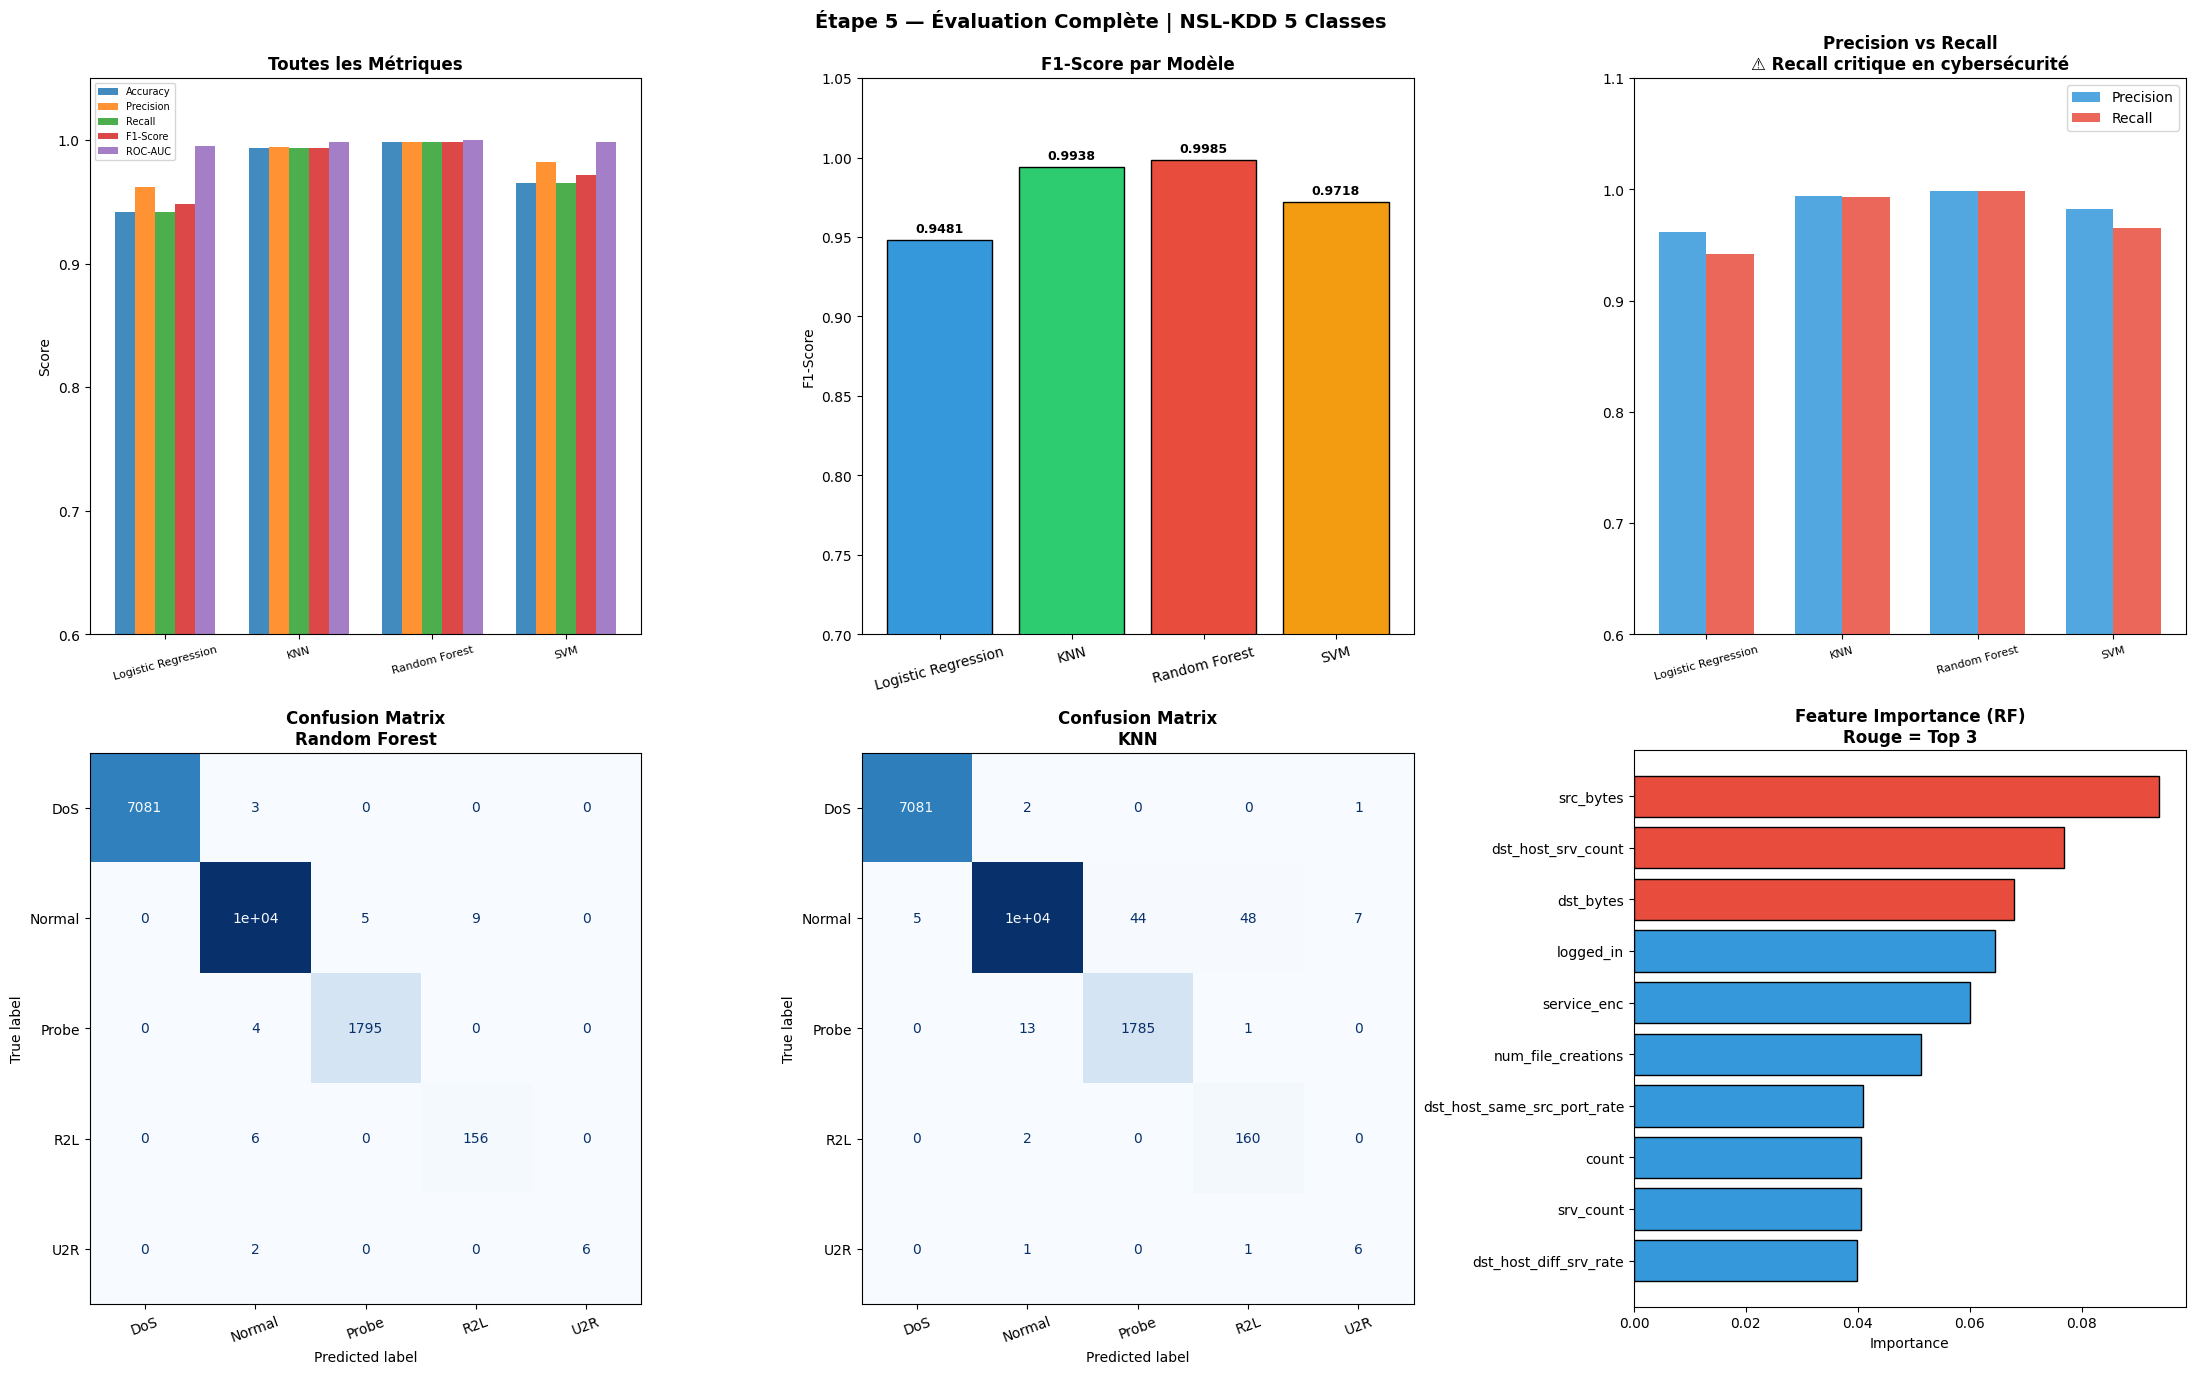

✅ evaluation_complete.png sauvegardé


In [18]:
print("=== ÉTAPE 5 — ÉVALUATION COMPLÈTE ===\n")
classes_sorted = sorted(df['attack_class'].unique())

# Reports détaillés
for name in results:
    print(f"\n📋 Classification Report — {name} :")
    print(classification_report(
        y_test, results[name]['y_pred'],
        target_names=classes_sorted, zero_division=0
    ))

# Graphiques
fig = plt.figure(figsize=(22, 14))
colors_bar = ['#3498db','#2ecc71','#e74c3c','#f39c12']
model_names = list(results.keys())

# 1. Toutes métriques
ax1 = fig.add_subplot(2, 3, 1)
metrics_list = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x = np.arange(len(model_names))
w = 0.15
for i, metric in enumerate(metrics_list):
    ax1.bar(x + i*w, df_results[metric], w, label=metric, alpha=0.85)
ax1.set_xticks(x + w*2)
ax1.set_xticklabels(model_names, rotation=15, fontsize=8)
ax1.set_ylim(0.6, 1.05)
ax1.set_title('Toutes les Métriques', fontweight='bold')
ax1.legend(fontsize=7)
ax1.set_ylabel('Score')

# 2. F1-Score
ax2 = fig.add_subplot(2, 3, 2)
bars = ax2.bar(model_names, df_results['F1-Score'],
               color=colors_bar, edgecolor='black')
ax2.set_ylim(0.7, 1.05)
ax2.set_title('F1-Score par Modèle', fontweight='bold')
ax2.set_ylabel('F1-Score')
ax2.tick_params(axis='x', rotation=15)
for bar, val in zip(bars, df_results['F1-Score']):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

# 3. Precision vs Recall
ax3 = fig.add_subplot(2, 3, 3)
x2 = np.arange(len(model_names))
w2 = 0.35
ax3.bar(x2 - w2/2, df_results['Precision'], w2,
        label='Precision', color='#3498db', alpha=0.85)
ax3.bar(x2 + w2/2, df_results['Recall'], w2,
        label='Recall', color='#e74c3c', alpha=0.85)
ax3.set_xticks(x2)
ax3.set_xticklabels(model_names, rotation=15, fontsize=8)
ax3.set_ylim(0.6, 1.1)
ax3.set_title('Precision vs Recall\n⚠️ Recall critique en cybersécurité',
              fontweight='bold')
ax3.legend()

# 4 & 5. Matrices de confusion (2 meilleurs)
top2 = df_results.nlargest(2, 'F1-Score')['Modèle'].tolist()
for idx, name in enumerate(top2):
    ax = fig.add_subplot(2, 3, 4 + idx)
    cm = confusion_matrix(y_test, results[name]['y_pred'],
                           labels=classes_sorted)
    disp = ConfusionMatrixDisplay(cm, display_labels=classes_sorted)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)

# 6. Feature Importance
ax6 = fig.add_subplot(2, 3, 6)
top10 = feat_imp.head(10)
colors_feat = ['#e74c3c' if i < 3 else '#3498db' for i in range(len(top10))]
ax6.barh(top10['feature'], top10['importance'],
         color=colors_feat, edgecolor='black')
ax6.set_title('Feature Importance (RF)\nRouge = Top 3', fontweight='bold')
ax6.set_xlabel('Importance')
ax6.invert_yaxis()

plt.suptitle('Étape 5 — Évaluation Complète | NSL-KDD 5 Classes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation_complete.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ evaluation_complete.png sauvegardé")

=== COURBES ROC — Multi-Classes (Micro-Average) ===


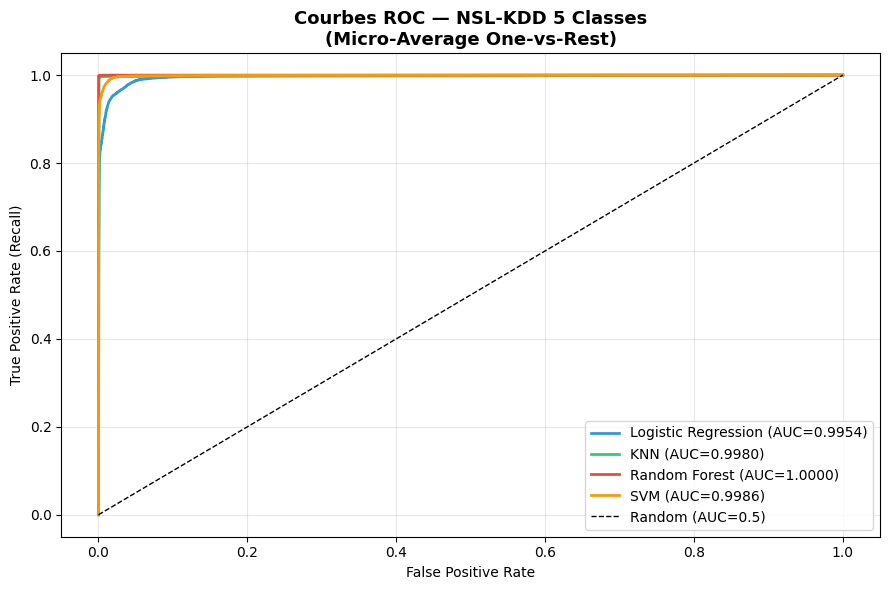

✅ roc_curves.png sauvegardé
=== SAUVEGARDE DU MEILLEUR MODÈLE ===

✅ best_model.pkl   → Random Forest
✅ scaler.pkl
✅ model_info.json
✅ clean_network_dataset.csv

🏆 Performances du meilleur modèle (Random Forest) :
   Accuracy  : 0.9985
   F1-Score  : 0.9985
   ROC-AUC   : 1.0000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  best_model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  roc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  data_split.png


In [20]:
print("=== COURBES ROC — Multi-Classes (Micro-Average) ===")

plt.figure(figsize=(9, 6))
colors_roc = ['#3498db','#2ecc71','#e74c3c','#f39c12']
y_test_bin = pd.get_dummies(y_test).reindex(
    columns=sorted(df['attack_class'].unique()), fill_value=0)

for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test_bin.values.ravel(), v['y_proba'].ravel())
    auc = v['auc']
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC={auc:.4f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Courbes ROC — NSL-KDD 5 Classes\n(Micro-Average One-vs-Rest)',
          fontweight='bold', fontsize=13)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("✅ roc_curves.png sauvegardé")
"""

# ╔══════════════════════════════════════════════╗
# ║  CELLULE 16 — Sauvegarde modèle + download ║
# ╚══════════════════════════════════════════════╝
"""
print("=== SAUVEGARDE DU MEILLEUR MODÈLE ===\n")

# Choisir le meilleur modèle
model_objects = {
    'Logistic Regression': lr_model,
    'KNN'                : best_knn,
    'Random Forest'      : rf_model,
    'SVM'                : svm_model,
}
best_obj = model_objects[best_model_name]

# Sauvegarder
joblib.dump(best_obj, 'best_model.pkl')
joblib.dump(scaler,   'scaler.pkl')

model_info = {
    'model_name' : best_model_name,
    'features'   : X.columns.tolist(),
    'n_features' : len(X.columns),
    'classes'    : sorted(df['attack_class'].unique()),
    'accuracy'   : float(results[best_model_name]['accuracy']),
    'precision'  : float(results[best_model_name]['precision']),
    'recall'     : float(results[best_model_name]['recall']),
    'f1_score'   : float(results[best_model_name]['f1']),
    'roc_auc'    : float(results[best_model_name]['auc']),
    'dataset'    : 'NSL-KDD',
    'task'       : 'multi-class (5 classes)',
    'attack_classes': {
        'Normal': 'Trafic réseau normal',
        'DoS'   : 'Déni de service (neptune, smurf, back...)',
        'Probe' : 'Reconnaissance réseau (nmap, ipsweep, portsweep...)',
        'R2L'   : 'Accès distant non autorisé (guess_passwd, ftp_write...)',
        'U2R'   : 'Escalade de privilèges root (buffer_overflow, rootkit...)',
    }
}

with open('model_info.json', 'w', encoding='utf-8') as f:
    json.dump(model_info, f, indent=2, ensure_ascii=False)

print(f"✅ best_model.pkl   → {best_model_name}")
print(f"✅ scaler.pkl")
print(f"✅ model_info.json")
print(f"✅ clean_network_dataset.csv")
print(f"\n🏆 Performances du meilleur modèle ({best_model_name}) :")
print(f"   Accuracy  : {results[best_model_name]['accuracy']:.4f}")
print(f"   F1-Score  : {results[best_model_name]['f1']:.4f}")
print(f"   ROC-AUC   : {results[best_model_name]['auc']:.4f}")

# Télécharger tous les fichiers
from google.colab import files
for fname in ['best_model.pkl','scaler.pkl','model_info.json','clean_network_dataset.csv',
              'boxplots.png','class_distribution.png','correlation_matrix.png',
              'evaluation_complete.png','roc_curves.png','data_split.png']:
    try:
        files.download(fname)
        print(f"⬇️  {fname}")
    except:
        print(f"⚠️  {fname} non trouvé")

